House Price Prediction using Linear Regression  
**MainCrafts AI & ML Internship – Task 1**

1. Introduction
This project focuses on building and evaluating a Linear Regression model to predict house prices using the California Housing dataset. 
The objective is to understand the complete machine learning workflow, including data loading, exploratory data analysis, and data 
preprocessing, model training, evaluation, and visualisation.

2. Dataset Description
The California Housing dataset is a real-world dataset that contains information about housing prices in different regions of California. 
The dataset consists of multiple numerical features such as median income, housing age, average rooms, population, and geographical location. 
The target variable is the median house value.

In [50]:
import pandas as pd
from sklearn.datasets import fetch_california_housing

data = fetch_california_housing(as_frame=True)
df = pd.concat([data.data, data.target.rename("MedHouseVal")], axis=1)
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


3. Exploratory Data Analysis
Exploratory Data Analysis (EDA) is performed to understand the structure of the dataset, identify feature distributions, correlations, and 
check for missing values.

In [52]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


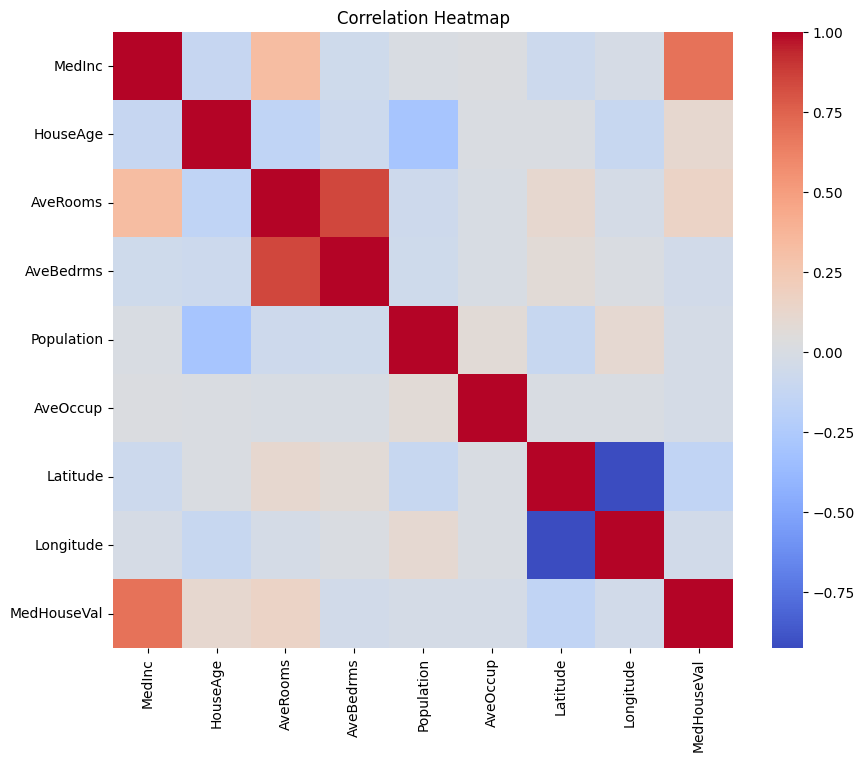

In [53]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

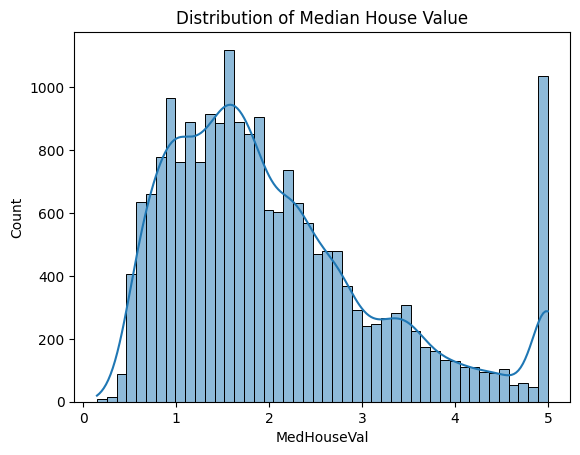

In [54]:
sns.histplot(df["MedHouseVal"], kde=True)
plt.title("Distribution of Median House Value")
plt.show()

4. Data Preprocessing
In this step, the dataset is prepared for model training by separating the input features and target variable. The data is then split into 
training and testing sets.

In [56]:
from sklearn.model_selection import train_test_split

X = df.drop(columns="MedHouseVal")
y = df["MedHouseVal"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

5. Model Training
A Linear Regression model is trained using the training dataset to learn the relationship between the input features and the target variable.

In [58]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

6. Model Evaluation
The performance of the trained model is evaluated using Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and R² score.

In [60]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error (MAE):", mae)
print("Root Mean Squared Error (RMSE):", rmse)
print("R² Score:", r2)

Mean Absolute Error (MAE): 0.5332001304956565
Root Mean Squared Error (RMSE): 0.745581383012776
R² Score: 0.5757877060324512


7. Results & Visualisation
The following scatter plot compares the actual house prices with the predicted house prices. A perfect prediction would align all points 
along the diagonal line.

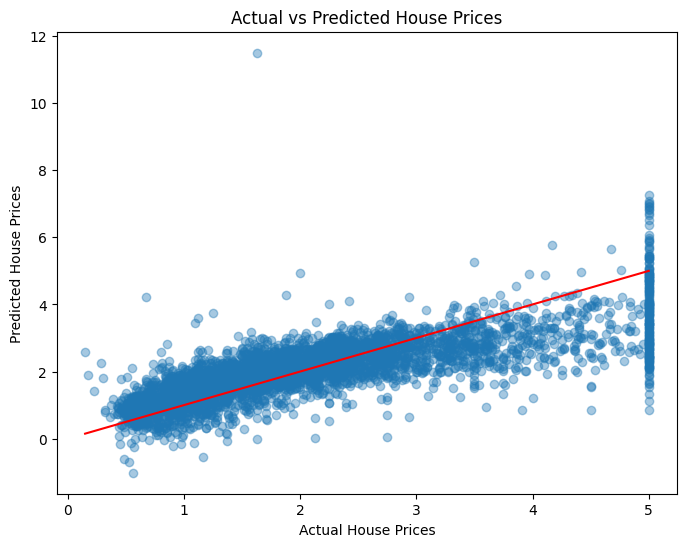

In [62]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.4)
plt.xlabel("Actual House Prices")
plt.ylabel("Predicted House Prices")
plt.title("Actual vs Predicted House Prices")
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()], 'r')
plt.show()

8. Conclusion & Future Scope
In this project, a Linear Regression model was successfully developed to predict house prices using the California Housing dataset. The model
demonstrated reasonable performance based on evaluation metrics.

Future enhancements may include:
- Feature scaling and normalisation
- Using advanced regression algorithms
- Hyperparameter tuning
- Incorporating additional datasets